# Fintech Customer Experience Analysis (EDA)

This notebook explores Google Play Store reviews from three Ethiopian banking apps:
- Commercial Bank of Ethiopia
- Bank of Abyssinia
- Dashen Bank

We perform:
- Basic exploratory data analysis (EDA)
- Sentiment distribution analysis
- Initial visualization of customer feedback patterns

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/clean_reviews.csv")

df.head()

,review,rating,date,bank,source
0,worst,1,2026-05-16,CBE,Google Play
1,this app very full,5,2026-05-16,CBE,Google Play
2,good apps,4,2026-05-16,CBE,Google Play
3,ok,5,2026-05-16,CBE,Google Play
4,this update got crazy i don't know what's goin...,1,2026-05-15,CBE,Google Play


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1500 non-null   str  
 1   rating  1500 non-null   int64
 2   date    1500 non-null   str  
 3   bank    1500 non-null   str  
 4   source  1500 non-null   str  
dtypes: int64(1), str(4)
memory usage: 58.7 KB


review    0
rating    0
date      0
bank      0
source    0
dtype: int64

In [3]:
df["rating"].value_counts()

rating
5    940
1    292
4    135
3     88
2     45
Name: count, dtype: int64

In [4]:
df.groupby("bank")["rating"].mean()

bank
BOA       3.566
CBE       4.122
Dashen    4.084
Name: rating, dtype: float64

In [5]:
df["bank"].value_counts()

bank
CBE       500
BOA       500
Dashen    500
Name: count, dtype: int64

## Sentiment Overview


In [6]:
sentiment_df = pd.read_csv("../data/raw/sentiment_results.csv")

sentiment_df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score
0,worst,1,2026-05-16,CBE,Google Play,NEGATIVE,0.999802
1,this app very full,5,2026-05-16,CBE,Google Play,POSITIVE,0.997449
2,good apps,4,2026-05-16,CBE,Google Play,POSITIVE,0.999861
3,ok,5,2026-05-16,CBE,Google Play,POSITIVE,0.999785
4,this update got crazy i don't know what's goin...,1,2026-05-15,CBE,Google Play,NEGATIVE,0.999513


In [7]:
sentiment_df["sentiment_label"].value_counts()

sentiment_label
POSITIVE    279
NEGATIVE    121
Name: count, dtype: int64

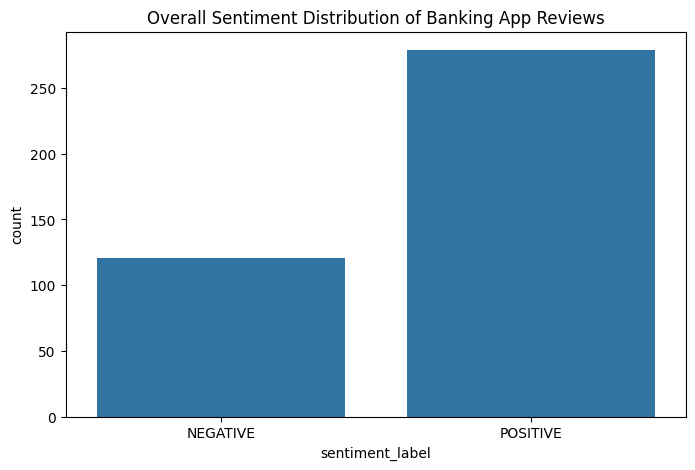

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=sentiment_df, x="sentiment_label")
plt.title("Overall Sentiment Distribution of Banking App Reviews")
plt.show()

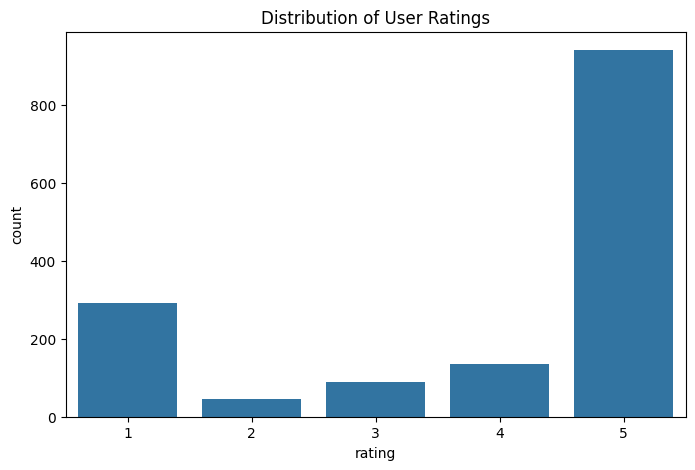

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="rating")
plt.title("Distribution of User Ratings")
plt.show()

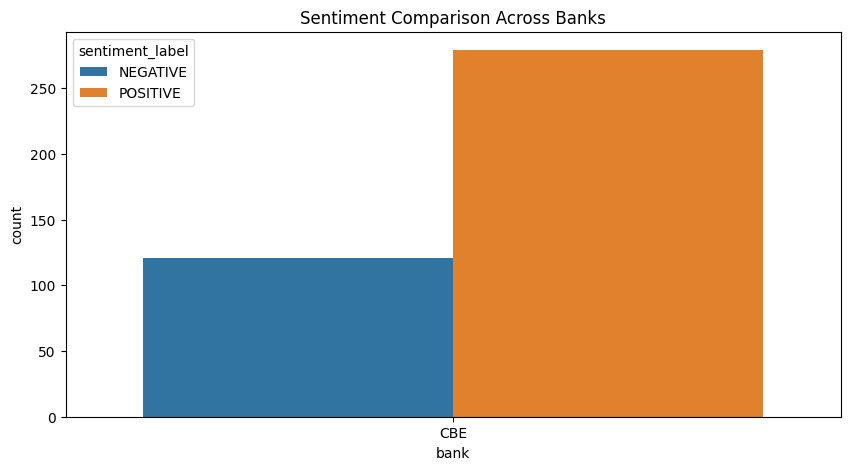

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=sentiment_df, x="bank", hue="sentiment_label")
plt.title("Sentiment Comparison Across Banks")
plt.show()

## Early Observations

- Most reviews are polarized (either positive or negative)
- Some banks show higher negative sentiment concentration
- Ratings and sentiment generally align, but not perfectly

In [11]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print("Total reviews:", len(df))

Missing values:
 review    0
rating    0
date      0
bank      0
source    0
dtype: int64
Duplicates: 23
Total reviews: 1500
